In [57]:
import numpy as np


import matplotlib.pyplot as mp
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D

#from mpl_toolkits.basemap import Basemap as bmap
import shapely.geometry as sgeom
import cftime
from datetime import timedelta

import xarray as xr
import datetime as dt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
from scipy import signal



In [58]:
def gauss_kern(size, sizey=None):
    """ Returns a normalized 2D gauss kernel array for convolutions """
    size = int(size)
    if not sizey:
        sizey = size
    else:
        sizey = int(sizey)
    x, y = np.mgrid[-size:size+1, -sizey:sizey+1]
    g = np.exp(-(x**2/float(size)+y**2/float(sizey)))
    return g / g.sum()

def blur_image(im, n, ny=None) :
    """ blurs the image by convolving with a gaussian kernel of typical
        size n. The optional keyword argument ny allows for a different
        size in the y direction.
    """
    g = gauss_kern(n, sizey=ny)
    improc = signal.convolve(im,g, mode='valid')
    return(improc)

In [86]:


date_range = ["0001-01-01","0002-01-01"]
vars_p = ['PRECT']


#run_names = ['f.e20.FHIST.f09_f09.cesm2_1.001','f.e20.FHIST.f09_f09.cesm2_1_cam5.001','f.e20.FHIST.f09_f09.cesm2_1_cam5_zmconv.001','f.e20.FHIST.f09_f09.cesm2_1_mg1.002','f.e20.FHIST.f09_f09.cesm2_1_revert125.001',
#                'f.e20.FHIST.f09_f09.cesm2_1_revertcam5param.001','f.e20.FHIST.f09_f09.cesm2_1_L30.001','f.e20.FHIST.f09_f09.cesm2_1_sb.001']
#case_names = ['CAM6','CAM5','zmconv','mg1','125','cam5-params','L30','sb1']
#run_names = ['f.e20.FHIST.f09_f09.cesm2_1.001','obs','obs']
#case_names = ['CAM6','TRMM','ERA5']

run_names = ['obs','obs']
case_names = ['TRMM','ERA5']

l2plot = True


#reg_a = [7.,12.,140.,160.]     ; reg_name = 'West Pacific'   # Central Pacific
#reg_a = [-5.,5.,160.,200.]     ; reg_name = 'Central Pacific'      # East Pacific
reg_a = [7.5,12,220.,240]  ; reg_name = 'East Pacific'      # West Pacific
#reg_a = [-20.,-5.,160.,200] ; reg_name = 'SPCZ'              # SPCZ


lrm_mean = True



#run_names = ['f.e20.FHIST.f09_f09.cesm2_1.001']
#case_names = np.array(['CAM6'])

#run_names = ['f.e20.FHIST.f09_f09_cesm2_1_cam5.001']
#case_names = np.array(['CAM5'])









#var_name = 'ZMDQ' ; vscale = 86400*1000. ; vunits = 'g/kg/day' ; long_name = 'Humidity Tendency due to Deep Convection'
#var_name = 'ZMDT' ; vscale = 86400. ; vunits = 'g/kg/day' ; long_name = 'Temperature Tendency due to Deep Convection'
#var_name = 'Q' ; vscale = 1000. ; vunits = 'g/kg' ; long_name = 'Specific Humidity'
#var_name = 'OMEGA' ; vscale = 0.01*3600. ; vunits = 'mb/day' ; long_name = 'Vertical Velocity'
#var_name = 'RVMTEND_CLUBB' ; vscale = 86400*1000. ; vunits = 'g/kg/day' ; long_name = 'Humidity Tendency due to CLUBB'
#var_name = 'CMFDQ' ; vscale = 86400*1000. ; vunits = 'g/kg/day' ; long_name = 'Humidity Tendency due to UW Shallow Convection'



-- Region ->  -140.0 7.5 -120.0 12

-Case - TRMM obs

Variable details ->  PRECT
Case details ->  TRMM
Run details ->  obs
Precipitation mm/day 86400000.0
0001-01-01 0002-01-01
-Case - ERA5 obs

Variable details ->  PRECT
Case details ->  ERA5
Run details ->  obs
Precipitation mm/day 86400000.0
0001-01-01 0002-01-01


/glade/work/rneale/python/miniconda3/envs/neale_myenv/lib/python3.8/site-packages/xarray/coding/times.py:716: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/glade/work/rneale/python/miniconda3/envs/neale_myenv/lib/python3.8/site-packages/xarray/core/indexing.py:529: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  return np.asarray(array[self.key], dtype=None)
/glade/work/rneale/python/miniconda3/envs/neale_myenv/lib/python3.8/site-packages/xarray/coding/times.py:716: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar,

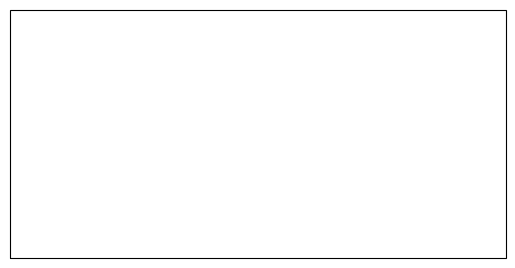

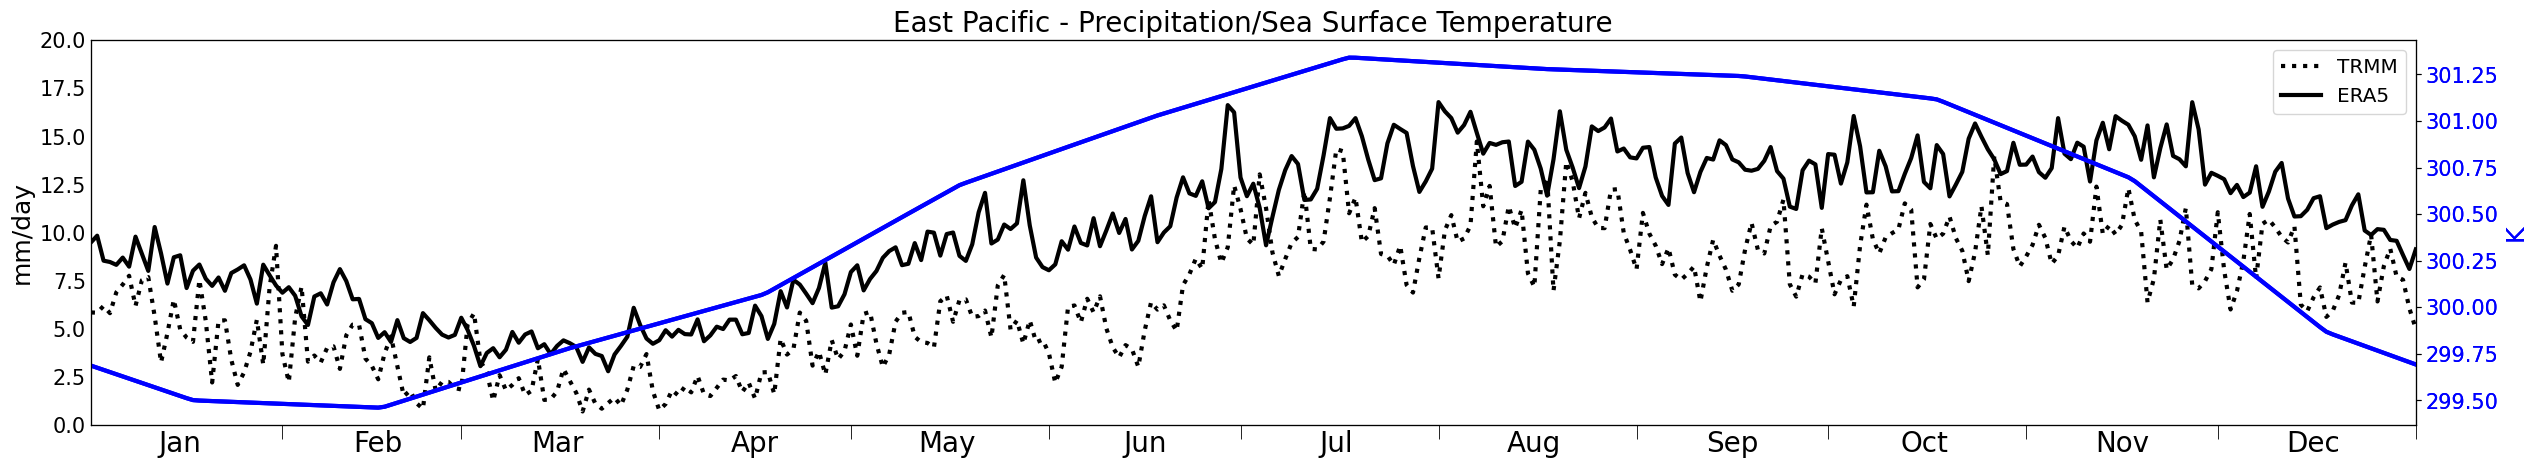

In [87]:
## Plots ##
pdir = '/glade/u/home/rneale/python/python-figs/vert_proc/transition_pod/'


## Derived ##

case_names = np.array(case_names)
vars_p = np.array(vars_p)

ncases = case_names.size
nvars = vars_p.size
# Region

reg_a_out = '%d-%dW_%.1f-%dN' % (360-reg_a[2],360-reg_a[3],reg_a[0],reg_a[1])
reg_a_str = '%d-%d\u00b0W %.1f-%d\u00b0N' % (360-reg_a[2],360-reg_a[3],reg_a[0],reg_a[1])

### Variables 
# Variables

vars_1d = ['TS','PRECT','LHFLX','OMEGA500','PREH2O']

variables = {}
variables['TS'] = ['Sea Surface Temperature','K',1.,301,303,2]  
variables['PRECT'] = ['Precipitation','mm/day',86400.*1000.,0,20,2] 
variables['LHFLX'] = ['Surface Latent Heat Flux','W/m^2',1.,70,200,2] 

variables['T'] = ['Temperature','K',1.,-2,2,0.2]  
variables['DIV'] = ['Divergence','/s',1.,-2e-5,2e-5,0.2e-5]  
variables['Q'] = ['Specific Humidity','g/kg',1000.,-2,2,0.2]  
variables['ZMDT'] = ['Temperature Tendency due to Deep Convection','K/day',86400,-5,5,1]  
variables['ZMDQ'] = ['Humidity Tendency due to Deep Convection','g/kg',86400.*1000.,-2,2,0.2] 
variables['OMEGA'] = ['Vertical Velocity','pa/s',1.,-0.05,0.05,0.005] 
variables['RVMTEND_CLUBB'] = ['Humidity Tendency due to Moist Turbulence','g/kg/day',86400*1000,-1,1,0.1] 
variables['DQDT'] = ['Resolved Humidity Tendency','g/kg/day',86400*1000,-1,1,0.1]

vars_df = pd.DataFrame.from_dict(variables, orient='index',columns=['long_name','vunits','vscale','cmin','cmax','dcont'])



## Plot map with averaging location

figm = mp.figure()

axm = figm.add_subplot(projection=ccrs.PlateCarree())

r1 = reg_a[2] if reg_a[3] <=180. else reg_a[2]-360.
r2 = reg_a[0] 
r3 = reg_a[3] if reg_a[3] <=180. else reg_a[3]-360.
r4 = reg_a[1] 


print('-- Region -> ',r1,r2,r3,r4)
print('')

extent_box = sgeom.box(r1,r2,r3,r4)

#axm.add_geometries([extent_box], ccrs.PlateCarree(), facecolor='none',
#                          edgecolor='blue', linewidth=2)
#axm.add_feature(cfeature.LAND)
#axm.add_feature(cfeature.COASTLINE)
#mp.show()


# DEFINED doy


# Offset Jan/Feb time problem
#time = time - timedelta(days=1)
#        nt = time.size

# Time format

date_form = DateFormatter("%b")
time = np.arange(1,366,1)

#time.dt.dayofyear




fig, axs = mp.subplots(1,1,figsize=(30, 5.))




########################
##### CASE LOOP   ######
########################

for ic in range(ncases):
    
    
    case = case_names[ic]
    run = run_names[ic]

    print('-Case - '+case+' '+run)
    
   
    
########################  
### VARIABLE LOOP ####
########################   

    for ivar,var in enumerate(vars_p) :
    
    
# Set axes for below.

        ax = axs
        if nvars==1: ax = axs  
#        if nvars>1:  ax = axs[ivar-2]
            
        lcol = 'black' ; lthick = 3 ; ldash = 'solid'
        if case == 'CAM6' : lcol = 'blue' ; lthick = 3 ; ldash = '-'
        if case == 'CAM5' : lcol = 'red'  ; lthick = 3 ; ldash = '-'
        if var == 'TS' : lcol = 'k'

        
        
# DF variable mete data for this variables       
        long_name = vars_df.loc[var]['long_name']
        vscale = vars_df.loc[var]['vscale']
        vunits = vars_df.loc[var]['vunits']
        cmin = vars_df.loc[var]['cmin'] ;  cmax = vars_df.loc[var]['cmax'] ;  dcont = vars_df.loc[var]['dcont'] 
        
        print()
        print('Variable details -> ',var)
        print('Case details -> ',case)
        print('Run details -> ',run)
              
        print(long_name,vunits,vscale)
    

        if var in vars_1d:
            print(date_range[0],date_range[1])
        
                         
            if run=='obs':
                
                if var == "PRECT" and case == 'ERA5':
                    ofile_in = '/glade/work/rneale/data/ERA5/PRECT.day.clim.nc'
                    ofile_ptr = xr.open_dataset(ofile_in,engine='netcdf4')
                    var_in = 24.*1000.*ofile_ptr[var].loc[:,reg_a[0]:reg_a[1],reg_a[2]:reg_a[3]]   
                    ldash = '-'
                    
                if var == "LHFLX" and case == 'ERA5':
                    ofile_in = '/glade/work/rneale/data/ERA5/LHFLX.day.clim.nc'
                    ofile_ptr = xr.open_dataset(ofile_in,engine='netcdf4')
                    var_in = -(1./3600.)*ofile_ptr[var].loc[:,reg_a[0]:reg_a[1],reg_a[2]:reg_a[3]]   
                    ldash = '-'
                    
                    
                
                
                
                if var == "PRECT" and case == 'TRMM':
                    ofile_in = '/glade/work/rneale/data/TRMM/TRMM.PRECT.30.N-30.S_ann_anoms.nc'
                    ofile_ptr = xr.open_dataset(ofile_in,engine='netcdf4')
                    var_in = ofile_ptr['PRECT_ACYCLE'].loc[:,reg_a[0]:reg_a[1],reg_a[2]:reg_a[3]]    
                    ldash = 'dotted'
                    
                
                
                
                
                    
            else:
                
                # Read in datat
                file_in = '/glade/scratch/rneale/'+run+'/tseries/'+run+'_clim_dmeans_ts_'+var+'.nc'
       
                file_ptr = xr.open_dataset(file_in,engine='netcdf4')
                
                var_in = vscale*file_ptr[var].loc[date_range[0]:date_range[1],reg_a[0]:reg_a[1],reg_a[2]:reg_a[3]] 
                    
                    
        else:

            file_in = '/glade/scratch/rneale/'+run+'/tseries/'+run+'_clim_dmeans_ts_'+var+'.nc'
       
            file_ptr = xr.open_dataset(file_in,engine='netcdf4')
            
            if var=='div':
                var_in = vscale*file_ptr[var].loc[date_range[0]:date_range[1],:,reg_a[0]:reg_a[1],reg_a[2]:reg_a[3]] 
       
#        var_in = var_in.groupby("time.dayofyear")

# Scale avergae set time ertc.
        var_m =  var_in.mean(dim=['lat','lon'])
    
      
        
#        var_m.values = signal.savgol_filter(var_m, 51, 3) # window size 51, polynomial order 3
        
# Filter
#        if var not in vars_1d:
#            for ii in range(0,10): #Simple multiple passes of a 1-2-1 filter
#                var_m[:,1:nt-2] = 0.25*(var_m[:,0:nt-3].values+2*var_m[:,1:nt-2].values+var_m[:,2:nt-1].values)
    
        
        
        

########################
####### PLOTTING #######
########################


       
    
# Lines at x-axis minor points + no length major ticks and no actual labels.
        ax.grid(axis = 'x', which='major')
        ax.xaxis.set_ticklabels([])
        ax.tick_params(which='major', length=0)
    
    
# LINE OR COUTOUR PLOT #
        if var in vars_1d:
    
 #           ax.set_title(long_name+' ('+vunits+')',fontsize=20)
    
 #           if lrm_mean : var_m = var_m - var_m.mean(dim='time')
            ax.plot(time,var_m,color = lcol, linestyle=ldash, linewidth=lthick)  
            ax.set_xlim([1, 365])
            ax.tick_params(axis="y", labelsize=15)
        
            if l2plot and ivar==0:
#                file_in = '/glade/work/rneale/data/ERA5/LHFLX.day.clim.nc'
                var_right = 'TS'
                run_right = 'f.e20.FHIST.f09_f09.cesm2_1.001'
                vscale_right = 1.
                # vscale_right = -1./36000.   # LHFLX
        
                file_in = '/glade/scratch/rneale/'+run_right+'/tseries/'+run_right+'_clim_dmeans_ts_'+var_right+'.nc'
                file_ptr = xr.open_dataset(file_in,engine='netcdf4')
                var_in = vscale_right*file_ptr[var_right].loc[:,reg_a[0]:reg_a[1],reg_a[2]:reg_a[3]]   
                ldash = 'dashed'
                var_m =  var_in.mean(dim=['lat','lon'])
                ax2 = ax.twinx()  # instantiate a second axes that shares the same x-axis
                ax2.plot(time,var_m,color = 'blue', linestyle='-', linewidth=lthick)    
               

                color = 'blue'
                
                ax.set_title(reg_name+' - '+long_name+'/Sea Surface Temperature',fontsize=20)
                ax2.tick_params(axis="y", labelsize=15)
                ax2.set_ylabel('K', color=color,fontsize=18)  # we already handled the x-label with ax1
#                ax2.plot(t, data2, color=color)
                ax2.tick_params(axis='y', labelcolor=color)  
        
            
#            if var == 'PRECT' and case in ['ERA5','TRMM']:
#                ax[ivar].plot(var_m.time,ovar,lw=3,color = 'k',linestyle='dashed')  
                
            ax.set_ylim([cmin, cmax])                
            ax.set_ylabel(vunits,fontsize=18) 
            
            
        else:
    
    # Pressure levels    
            plev = np.arange(100.,1000.,100)
            lev = var_m.lev
            nlev = lev.size
            
            if (lrm_mean) :
                var_mean = var_m.mean(dim='time')
                for ipp in range(nlev):
                    var_m[:,ipp] = var_m[:,ipp] - var_mean[ipp]
            
            var_m = var_m.transpose()
        
 
            # Contours
            plevels =  np.arange(cmin,cmax+dcont,dcont,dtype=np.double)
            plevels = plevels[plevels!=0]
    
            ax.set_title(case+' - '+long_name+' ('+vunits+')',fontsize=20)
    
            ax.invert_yaxis()
            ax.set_ylabel('Pressure (mb)',fontsize=15) 
            ax.set_yticks(plev)
            ax.set_yticklabels(plev.astype(int))
#    ax[ic].set_yticklabels(lev.astype(int),fontsize=15)
            ax.tick_params(axis="y", labelsize=12)
            
            ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
       
           
            aplot = ax.contourf(time,lev,var_m,levels=plevels,cmap='BrBG')
            fig.colorbar(aplot)

            aplot = ax.contour(time,lev,var_m,levels=plevels,colors='black',linewidths=0.5)
            ax.clabel(aplot, aplot.levels,fmt='%3.2f')
#           aplot = ax[ivar].contour(doy,lev,var_m,levels=[0],colors='black',linewidths=3,linestyles='dashed')
   
        ax.xaxis.set_minor_locator(mdates.MonthLocator())
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=16))
        ax.tick_params(which='minor', length=10)
        

    #Options for all the plots.
    
    mp.rcParams['xtick.labelsize']=20 # GLobal set of xtick label size

    ####### Xaxis labels (Month) for last plot only.
    ax.xaxis.set_major_formatter(date_form)
    ax.tick_params(axis="x", labelsize=20)
    ax.axes.xaxis.set_visible(True)

    
#    colors = ['black', 'black', 'blue']
#    lines = [Line2D([0], [0], color=c, linewidth=3, linestyle='-') for c in colors]
 #   print(lines)
 #   labels = np.append(case_names,'HadISST')
 #   mp.legend(lines, labels)

    
    
#    lns = ax+axs
#    labs = [l.get_label() for l in lns]
#    ax.legend(lns, labs, loc=0)
#    print(var)
#    print(np.append(case_names,'HadISST'))
    
    if var in vars_1d: axs.legend(np.append(case_names,'HadISST'),fontsize='x-large')
#    ax[0].legend(['CAM6','CAM5','dev run',',leg_labels,fontsize=15,loc = lloc)
#                  axn[0,0].legend(leg_elements,leg_labels,fontsize=15,loc = lloc)

    ## FILE OUTPUT FOR THIS CASE ##
ptitle = case+' - '+reg_a_str
 #   mp.suptitle(ptitle,fontsize=20)
mp.savefig('single_lev_daily_ts.plev_TS_PRECT_'+case+'_'+reg_a_out+'_'+date_range[0]+'_to_'+date_range[1]+'.png', dpi=80)  
    